## **Importing Packages and libraries**

In [1]:
! pip install seqeval
!pip install pytorch-crf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 735.3 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=ef049ff4209e16e384b9b5a9817d044c2d9a7fa442fdb5b112013c52e487a2bc
  Stored in directory: /root/.cache/pip/wheels/1a/67/4a/ad4082dd7dfc30f2abfe4d80a2ed5926a506eb8a972b4767fa
Successfully built seqeval


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import BertTokenizer , BertTokenizerFast
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
from seqeval.metrics import classification_report , precision_score , recall_score , f1_score
import torch
import torchcrf
from torch import nn
from torchcrf import CRF

pd.set_option("display.max_rows",10)
pd.set_option("display.max_column",10)
pd.set_option("display.width",100)
pd.set_option("display.max_colwidth",None)
CUDA_LAUNCH_BLOCKING=1

2024-04-27 22:45:30.608116: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-27 22:45:30.608167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-27 22:45:30.609562: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## **Importing data**

In [3]:
data = pd.read_csv(r"/kaggle/input/ner-dataset/ner_datasetreference.csv",encoding="unicode_escape")

## **Exploring data**

In [4]:
data.head()

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


In [5]:
data.shape

(1048575, 4)

In [6]:
data.isnull().sum()

Sentence #    1000616
Word               10
POS                 0
Tag                 0
dtype: int64

In [7]:
data.ffill(axis=0,inplace=True)

In [8]:
data.isnull().sum()

Sentence #    0
Word          0
POS           0
Tag           0
dtype: int64

In [9]:
data.head()

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O


In [10]:
labels_to_ids = {'O': 0,'B-nat': 1 , 'I-nat' : 2, 'B-eve' : 3, 'I-eve': 4, 'B-art': 5, 'I-art' : 6, 'B-org': 7,
 'I-org': 8 , 'B-tim': 9, 'I-tim' : 10, 'B-per': 11 , 'I-per': 12, 'B-geo': 13 , 'I-geo': 14 , 'B-gpe': 15 ,
 'I-gpe': 16 } 

In [11]:
ids_to_labels = {}
for label , id in labels_to_ids.items() :
    ids_to_labels[id] = label
print(ids_to_labels)

{0: 'O', 1: 'B-nat', 2: 'I-nat', 3: 'B-eve', 4: 'I-eve', 5: 'B-art', 6: 'I-art', 7: 'B-org', 8: 'I-org', 9: 'B-tim', 10: 'I-tim', 11: 'B-per', 12: 'I-per', 13: 'B-geo', 14: 'I-geo', 15: 'B-gpe', 16: 'I-gpe'}


In [12]:
visualizing_data = data[data["Tag"] != "O"]
order = visualizing_data["Tag"].value_counts().index

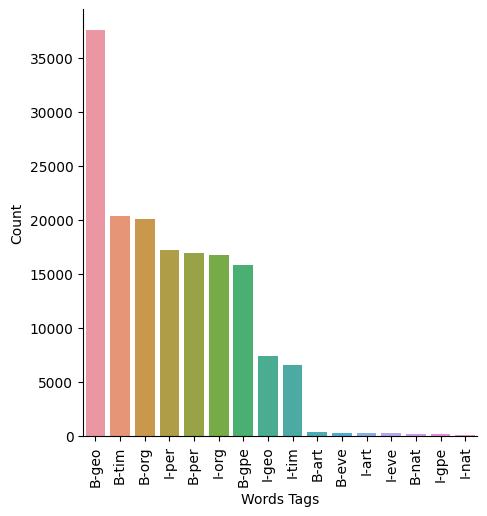

In [13]:
ax = sns.catplot(kind="count",x="Tag",data=visualizing_data,order=order)
ax.set_xlabels("Words Tags")
ax.set_ylabels("Count")
ax.set_titles("Tags count")
plt.xticks(rotation =90)
plt.show()

## **Preproceessing text**

In [14]:
words = set(data["Word"])
len(words)

35177

In [15]:
data["Tag"] = data["Tag"].map(labels_to_ids)

In [16]:
pd.set_option("display.max_colwidth",None)

In [17]:
grouped_data = data.groupby(["Sentence #"]).apply(lambda x : pd.Series({"tokenized_sentences" : x["Word"].tolist() , "Tags" :x["Tag"].tolist()})).reset_index()
grouped_data.drop("Sentence #",inplace=True,axis=1)

/tmp/ipykernel_99/4006688708.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_data = data.groupby(["Sentence #"]).apply(lambda x : pd.Series({"tokenized_sentences" : x["Word"].tolist() , "Tags" :x["Tag"].tolist()})).reset_index()


In [18]:
grouped_data.head()

,tokenized_sentences,Tags
0,"[Thousands, of, demonstrators, have, marched, through, London, to, protest, the, war, in, Iraq, and, demand, the, withdrawal, of, British, troops, from, that, country, .]","[0, 0, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 15, 0, 0, 0, 0, 0]"
1,"[Iranian, officials, say, they, expect, to, get, access, to, sealed, sensitive, parts, of, the, plant, Wednesday, ,, after, an, IAEA, surveillance, system, begins, functioning, .]","[15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 7, 0, 0, 0, 0, 0]"
2,"[Helicopter, gunships, Saturday, pounded, militant, hideouts, in, the, Orakzai, tribal, region, ,, where, many, Taliban, militants, are, believed, to, have, fled, to, avoid, an, earlier, military, offensive, in, nearby, South, Waziristan, .]","[0, 0, 9, 0, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 13, 14, 0]"
3,"[They, left, after, a, tense, hour-long, standoff, with, riot, police, .]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,"[U.N., relief, coordinator, Jan, Egeland, said, Sunday, ,, U.S., ,, Indonesian, and, Australian, military, helicopters, are, ferrying, out, food, and, supplies, to, remote, areas, of, western, Aceh, province, that, ground, crews, can, not, reach, .]","[13, 0, 0, 11, 12, 0, 9, 0, 13, 0, 15, 0, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 0]"


In [19]:
tokenier = BertTokenizerFast.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [20]:
grouped_data["tokens"] = grouped_data["tokenized_sentences"].apply(lambda x : tokenier(x, is_split_into_words = True)["input_ids"])

In [21]:
sentences_length = []
for sentence in grouped_data["tokens"] :
    sentences_length.append(len(sentence))

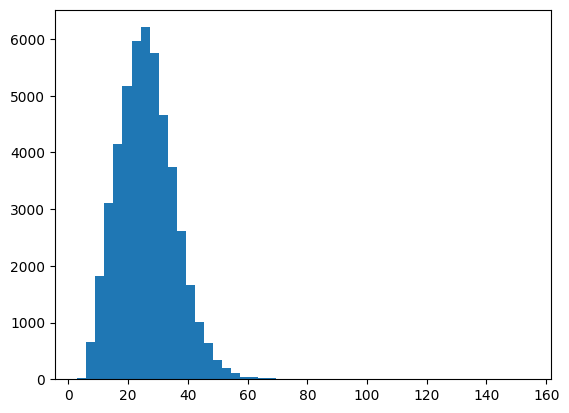

In [22]:
plt.hist(sentences_length,bins=50) ;


In [23]:
np.average(sentences_length)

26.539314831418505

In [24]:
def align_labels_with_tokens(labels,word_ids) :
    prev_word = None
    new_labels = []

    for id in word_ids :
        if id != prev_word :
            prev_word = id
            label = 0 if prev_word == None else labels[id]
            new_labels.append(label)
        elif prev_word == None :
            new_labels.append(0)
        else :
            label = labels[id]
            if label % 2 ==1 :
                label += 1

            new_labels.append(label)

    return new_labels

In [25]:
def tokenize_and_align_labels(row) :
    tokenized_sentence = tokenier(row["tokenized_sentences"], is_split_into_words = True)
    word_ids = tokenized_sentence.word_ids()
    labels_ids = row["Tags"]

    new_labels = align_labels_with_tokens(labels_ids,word_ids)
    return  new_labels

In [26]:
grouped_data["new_tags" ] = grouped_data.apply(lambda x : tokenize_and_align_labels(x) , axis = 1)

## **Building Model**

In [27]:
print(torch.__version__)

2.1.2


In [28]:
gpus = torch.cuda.device_count()
for i in range(gpus) :
    print(torch.cuda.get_device_name(i))

Tesla T4
Tesla T4


In [29]:
device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')

In [30]:
device

device(type='cuda', index=0)

In [31]:
class ClassificationModel(nn.Module) :
    def __init__(self, vocab_size , embed_dim , hidden_dim , tag_size) :
        super().__init__()

        self.word_embedds = nn.Embedding(vocab_size,embed_dim)
        self.dropout = nn.Dropout(0.2)
        self.lstm = nn.LSTM(embed_dim,hidden_size=hidden_dim//2 , bidirectional=True , batch_first=True , num_layers= 2)
        self.linear = nn.Linear(hidden_dim , tag_size)
        self.crf = CRF(tag_size,batch_first=True)
        

    def forward(self,input,tags=None,masks=None) :
        embedded_input = self.word_embedds(input)
        embedded_input_dropout = self.dropout(embedded_input)
        lstm_out , _ = self.lstm(embedded_input_dropout)
        lstm_dropout = self.dropout(lstm_out)
        linear_output = self.linear(lstm_dropout)
        
        if tags != None :
            output = -self.crf(linear_output,tags,masks)
        else :
            output = self.crf.decode(linear_output)
            output = torch.tensor(output).to(device)
            
        return output

In [32]:
vocab_size = len(tokenier.vocab)
embed_dim = 300
hidden_dim = 256 
tag_size = len(labels_to_ids)
max_length = 60

In [33]:
model = ClassificationModel(vocab_size,embed_dim,hidden_dim,tag_size)

In [34]:
model = model.to(device)

## **DataLoader**

In [35]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [36]:
class ReviewDataset(Dataset) :
    def __init__(self,sentences_tokens , tags , tokenizer ):
        tensor_tokens = [torch.tensor(seq) for seq in sentences_tokens]
        padded_tensor_tokens =  pad_sequences(tensor_tokens , maxlen=max_length , padding="post" , value=tokenizer.get_vocab()['[PAD]'])
        tensor_tags = [torch.tensor(tag) for tag in tags]
        self.mask = [torch.ones(len(seq)) for seq in tensor_tags]
        self.mask = torch.tensor(pad_sequences(self.mask , maxlen=max_length , padding="post",value=0),dtype=torch.uint8)
        padded_tensor_tags = pad_sequences(tensor_tags , maxlen=max_length , padding="post",value=0)
        self.sentences_tokens = padded_tensor_tokens
        self.tags =  padded_tensor_tags

    def __len__(self) :
        return len(self.sentences_tokens)
    
    def __getitem__(self, index) :
        sentence_token = self.sentences_tokens[index]
        target = self.tags[index]
        masks = self.mask[index]
        
        return {"tokens" : sentence_token , "tags" : target , "masks" : masks }

In [37]:
def get_data_loader(df, batch_size , tokenizer) :
    dataset = ReviewDataset(df.tokens , df.new_tags , tokenizer)
    return DataLoader(dataset,batch_size=batch_size,pin_memory=True,num_workers=0)

## **Splitting Dataset**

In [38]:
training_data , validation_data = train_test_split(grouped_data,test_size=.15)
validation_data , testing_data = train_test_split(validation_data,test_size=.5)

In [39]:
training_data_loader = get_data_loader(training_data, batch_size=16 , tokenizer=tokenier)
validation_data_loader = get_data_loader(validation_data, batch_size=16 , tokenizer=tokenier)
testing_data_loader = get_data_loader(testing_data, batch_size=16 , tokenizer=tokenier)

In [40]:
EPOCHS = 10
training_steps = EPOCHS * len(training_data_loader)
optimizer = AdamW(model.parameters(),lr= .001)
warmup_steps = int( .2 * training_steps)
scheduler = get_linear_schedule_with_warmup(optimizer=optimizer,num_warmup_steps=warmup_steps,num_training_steps=training_steps)

In [41]:
def get_labels(ids_batchs) :
    labels = []
    for id_batch in ids_batchs:
        for seq in id_batch :
            sequence_labels = [ids_to_labels[id] for id in list(seq)]
            labels.append(sequence_labels)
    return labels

In [42]:
def train_epoch(model,data_loader) :
    model.train()
    losses = []
    all_predictions = []
    all_labels = []

    for d in tqdm(data_loader) :
        optimizer.zero_grad()
        tokens = d["tokens"].to(device)
        tags = d["tags"].to(device)
        masks = d["masks"].to(device)

        predictions = model(tokens)
        
        all_predictions.append(list(predictions.cpu().numpy()))
        all_labels.append(list(tags.cpu().numpy()))
        
        loss = model(tokens,tags,masks)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        scheduler.step()

    all_predictions_flat = get_labels(all_predictions)
    all_labels_flat = get_labels(all_labels)
    # Calculate evaluation metrics
    precision = precision_score(all_predictions_flat , all_labels_flat, average = 'weighted')
    recall = recall_score(all_predictions_flat , all_labels_flat, average = 'weighted')
    f_score = f1_score(all_predictions_flat , all_labels_flat, average = 'weighted')
    

    return np.average(losses) , precision , recall , f_score

In [43]:
def evaluate_model(model,data_loader) :
    model.eval()
    losses = []
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for d in tqdm(data_loader) :
            tokens = d["tokens"].to(device)
            tags = d["tags"].to(device)
            masks = d["masks"].to(device)

            predictions = model(tokens)
            loss = model(tokens,tags,masks)
            all_predictions.append(list(predictions.cpu().numpy()))
            all_labels.append(list(tags.cpu().numpy()))
            losses.append(loss.item())

    all_predictions_flat = get_labels(all_predictions)
    all_labels_flat = get_labels(all_labels)
    # Calculate evaluation metrics
    precision = precision_score(all_predictions_flat , all_labels_flat, average = 'weighted')
    recall = recall_score(all_predictions_flat , all_labels_flat, average = 'weighted')
    f_score = f1_score(all_predictions_flat , all_labels_flat, average = 'weighted')

    return np.average(losses) , precision , recall , f_score

In [44]:
best_score = 0
for epoch in range(EPOCHS) :
    print(f"Epoch {epoch}")
    training_loss , training_precision , training_recall , training_f1_score = train_epoch(model,training_data_loader)
    validation_loss , validation_precision , validation_recall , validation_f1_score = evaluate_model(model,validation_data_loader)

    print(f"Training loss : {training_loss} , Training precision : {training_precision} , Training recall : {training_recall} , Training f1_score : {training_f1_score} ")
    print(f"Validation loss : {validation_loss} , Validation precision : {validation_precision} , Validation recall : {validation_recall} , Validation f1_score : {validation_f1_score} ")

    if validation_f1_score > best_score :
        torch.save(model.state_dict(),"best_model.bin")
    

Epoch 0


  0%|          | 0/2548 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/torchcrf/__init__.py:305: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorCompare.cpp:519.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)
100%|██████████| 225/225 [00:11<00:00, 18.90it/s]
/opt/conda/lib/python3.10/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Training loss : 257.009683812619 , Training precision : 0.25026986839933774 , Training recall : 0.2392804589199015 , Training f1_score : 0.23947671084748173 
Training loss : 82.73943483140734 , Training precision : 0.7109738348936742 , Training recall : 0.7456359102244389 , Training f1_score : 0.7204019637813748 
Epoch 1


100%|██████████| 225/225 [00:11<00:00, 19.05it/s]


Training loss : 64.88795935153213 , Training precision : 0.7309620695012726 , Training recall : 0.764321800712707 , Training f1_score : 0.7459254272870625 
Training loss : 46.944073062472874 , Training precision : 0.7890991441510109 , Training recall : 0.8101550775387694 , Training f1_score : 0.7951960846734711 
Epoch 2


...

Training loss : 12.865348344320779 , Training precision : 0.8970877630840053 , Training recall : 0.9054372765594152 , Training f1_score : 0.9008777785503181 
Training loss : 35.41820875379774 , Training precision : 0.8207273069920025 , Training recall : 0.8213944603629417 , Training f1_score : 0.8204562941642018 
Epoch 8


100%|██████████| 225/225 [00:11<00:00, 19.16it/s]


Training loss : 11.072564265791625 , Training precision : 0.9101214446612346 , Training recall : 0.9166294239077231 , Training f1_score : 0.9130264082260084 
Training loss : 36.347726304796005 , Training precision : 0.821191391762825 , Training recall : 0.8264927605600095 , Training f1_score : 0.8235236089798472 
Epoch 9


100%|██████████| 225/225 [00:11<00:00, 19.06it/s]


Training loss : 9.596059624029666 , Training precision : 0.9204253571980658 , Training recall : 0.9264252778309003 , Training f1_score : 0.9231761694413477 
Training loss : 36.66848249647352 , Training precision : 0.8239810695675304 , Training recall : 0.8315132605304212 , Training f1_score : 0.8273398802137575 
